# 2단계: 재료 파싱 및 정규화

## 목표
- 비정형 재료 텍스트에서 재료명 추출
- 재료 단위 및 수량 파싱
- 재료명 정규화 (동의어 처리)
- 재료 사전 구축

In [19]:
# 필수 라이브러리 임포트
import pandas as pd
import numpy as np
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import warnings

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')

print("라이브러리 로딩 완료")

라이브러리 로딩 완료


## 2.1 데이터 로딩

In [20]:
# 1단계에서 저장한 분석 데이터 로딩
import os

PROCESSED_PATH = '../data/processed/recipes_analyzed.csv'
RAW_PATH = '../data/recipe/TB_RECIPE_SEARCH_241226.csv'

if os.path.exists(PROCESSED_PATH):
    df = pd.read_csv(PROCESSED_PATH, encoding='utf-8-sig')
    print(f"분석 데이터 로딩: {len(df):,}개 레시피")
else:
    df = pd.read_csv(RAW_PATH, encoding='utf-8')
    print(f"원본 데이터 로딩: {len(df):,}개 레시피")

print(f"컬럼: {df.columns.tolist()}")

분석 데이터 로딩: 23,192개 레시피
컬럼: ['RCP_SNO', 'RCP_TTL', 'CKG_NM', 'CKG_MTRL_CN', 'INQ_CNT', 'RCMM_CNT', 'SRAP_CNT', 'CKG_KND_ACTO_NM', 'CKG_DODF_NM', 'CKG_TIME_NM', 'ingredient_count', 'popularity_score']


## 2.2 재료 파싱 규칙 정의

In [21]:
# 재료 파싱을 위한 정규표현식 패턴 정의

class IngredientParser:
    """재료 텍스트를 파싱하는 클래스 (개선된 버전)"""
    
    # 섹션 태그 패턴 (예: [재료], [양념], [소스])
    SECTION_PATTERN = re.compile(r'\[([^\]]+)\]')
    
    # 수량+단위 패턴 (더 강력한 버전)
    # 예: 400g, 1/2개, 1.5kg, 2T, 1큰술, 약간
    QUANTITY_UNIT_PATTERN = re.compile(
        r'(\d+(?:[./]\d+)?)\s*'  # 수량 (100, 1/2, 1.5 등)
        r'(g|kg|ml|L|l|cc|개|장|마리|대|줄|쪽|톨|뿌리|포기|봉|팩|컵|'
        r'T|t|큰술|작은술|숟가락|스푼|인분|꼬집|cm|송이)?'  # 단위
        r'$'  # 문자열 끝
    )
    
    # 비정량 표현 패턴
    VAGUE_PATTERN = re.compile(r'(약간|조금|적당량|적당히|톡톡|충분히|넉넉히|소량|솔솔|살짝)$')
    
    # 제외할 섹션 키워드
    EXCLUDE_SECTION_KEYWORDS = ['재료', '양념', '소스', '드레싱', '토핑', '장식', '기타', '육수', '국물']
    
    # 제어 문자 제거 패턴
    CONTROL_CHAR_PATTERN = re.compile(r'[\x00-\x1f\x7f-\x9f]')
    
    def __init__(self):
        self.ingredient_counter = Counter()
    
    def clean_text(self, text):
        """제어 문자 및 불필요한 문자 제거"""
        if not text:
            return ''
        # 제어 문자 제거 (\x07 등)
        text = self.CONTROL_CHAR_PATTERN.sub('', text)
        # 연속 공백 제거
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    
    def parse_ingredient_text(self, text):
        """
        재료 텍스트를 파싱하여 재료 목록을 반환
        
        Args:
            text: 원본 재료 텍스트 (예: '[재료] 떡국떡400g| 다진소고기100g| ...')
        
        Returns:
            list: 파싱된 재료 딕셔너리 리스트
        """
        if pd.isna(text) or not str(text).strip():
            return []
        
        text = self.clean_text(str(text))
        ingredients = []
        current_section = '재료'
        
        # | 구분자로 분리
        parts = text.split('|')
        
        for part in parts:
            part = self.clean_text(part)
            if not part:
                continue
            
            # 섹션 태그 확인 및 제거
            section_match = self.SECTION_PATTERN.search(part)
            if section_match:
                current_section = section_match.group(1)
                part = self.SECTION_PATTERN.sub('', part).strip()
            
            if not part:
                continue
            
            # 재료 파싱
            parsed = self._parse_single_ingredient(part)
            if parsed and parsed['name']:
                parsed['section'] = current_section
                ingredients.append(parsed)
        
        return ingredients
    
    def _parse_single_ingredient(self, text):
        """
        단일 재료 텍스트를 파싱하여 재료명만 추출
        
        Args:
            text: 단일 재료 텍스트 (예: '떡국떡400g', '다진마늘1T')
        
        Returns:
            dict: {'name': '떡국떡', 'quantity': '400', 'unit': 'g', 'raw': '떡국떡400g'}
        """
        text = self.clean_text(text)
        if not text:
            return None
        
        original_text = text
        quantity = None
        unit = None
        
        # 1. 끝에서부터 수량+단위 패턴 찾기
        # 예: "떡국떡400g" -> "떡국떡", "400", "g"
        match = self.QUANTITY_UNIT_PATTERN.search(text)
        if match:
            quantity = match.group(1)
            unit = match.group(2) or ''
            name = text[:match.start()].strip()
        else:
            # 2. 비정량 표현 찾기 (약간, 조금 등)
            vague_match = self.VAGUE_PATTERN.search(text)
            if vague_match:
                quantity = vague_match.group(1)
                unit = ''
                name = text[:vague_match.start()].strip()
            else:
                # 3. 숫자가 포함된 경우 숫자 이전까지를 재료명으로
                # 예: "양파1/2개" -> "양파"
                num_match = re.search(r'(\d)', text)
                if num_match:
                    name = text[:num_match.start()].strip()
                    rest = text[num_match.start():]
                    # 나머지에서 수량/단위 추출 시도
                    qty_match = re.match(r'(\d+(?:[./]\d+)?)\s*(\S*)', rest)
                    if qty_match:
                        quantity = qty_match.group(1)
                        unit = qty_match.group(2)
                else:
                    name = text
        
        # 재료명 정리
        name = self.clean_text(name)
        
        # 재료명이 비어있거나 섹션 키워드인 경우 무시
        if not name or name in self.EXCLUDE_SECTION_KEYWORDS:
            return None
        
        # 재료명이 너무 짧거나 숫자로만 이루어진 경우 무시
        if len(name) < 1 or name.isdigit():
            return None
        
        return {
            'name': name,
            'quantity': quantity,
            'unit': unit,
            'raw': original_text
        }

# 파서 인스턴스 생성
parser = IngredientParser()
print("IngredientParser 클래스 정의 완료 (개선된 버전)")

IngredientParser 클래스 정의 완료 (개선된 버전)


## 2.3 파싱 테스트

In [22]:
# 샘플 데이터로 파싱 테스트
INGREDIENT_COL = 'CKG_MTRL_CN'

# 샘플 재료 텍스트 5개 추출
samples = df[INGREDIENT_COL].dropna().head(5)

print("파싱 테스트 결과:")
print("=" * 80)

for i, sample in enumerate(samples, 1):
    print(f"\n[샘플 {i}]")
    print(f"원본: {sample[:100]}..." if len(str(sample)) > 100 else f"원본: {sample}")
    
    parsed = parser.parse_ingredient_text(sample)
    print(f"파싱 결과 ({len(parsed)}개 재료):")
    for ing in parsed[:5]:  # 상위 5개만 출력
        print(f"  - {ing['name']} (수량: {ing['quantity']}, 단위: {ing['unit']}, 섹션: {ing['section']})")
    if len(parsed) > 5:
        print(f"  ... 외 {len(parsed)-5}개")

파싱 테스트 결과:

[샘플 1]
원본: [재료] 떡국떡400g| 다진소고기100g| 멸치육수800ml| 대파1/3대| 계란2개| 참기름1T| 국간장1T| 참기름1/2T| 다진마...
파싱 결과 (11개 재료):
  - 떡국떡 (수량: 400, 단위: g, 섹션: 재료)
  - 다진소고기 (수량: 100, 단위: g, 섹션: 재료)
  - 멸치육수 (수량: 800, 단위: ml, 섹션: 재료)
  - 대파 (수량: 1/3, 단위: 대, 섹션: 재료)
  - 계란 (수량: 2, 단위: 개, 섹션: 재료)
  ... 외 6개

[샘플 2]
원본: [재료] 돼지고기 수육용삼겹살500g| 된장1.5큰술| 술4큰술| 홍어무침| 무생채| 콩나물무침
파싱 결과 (6개 재료):
  - 돼지고기 수육용삼겹살 (수량: 500, 단위: g, 섹션: 재료)
  - 된장 (수량: 1.5, 단위: 큰술, 섹션: 재료)
  - 술 (수량: 4, 단위: 큰술, 섹션: 재료)
  - 홍어무침 (수량: None, 단위: None, 섹션: 재료)
  - 무생채 (수량: None, 단위: None, 섹션: 재료)
  ... 외 1개

[샘플 3]
원본: [재료] 돼지등뼈1.5kg| 양파1/2개| 감자1개| 대파1대| 알배기배추1/2개| 청양고추2개| 깻잎10~15장 [양념] 된장2T| 고...
파싱 결과 (15개 재료):
  - 돼지등뼈 (수량: 1.5, 단위: kg, 섹션: 재료)
  - 양파 (수량: 1/2, 단위: 개, 섹션: 재료)
  - 감자 (수량: 1, 단위: 개, 섹션: 재료)
  - 대파 (수량: 1, 단위: 대, 섹션: 재료)
  - 알배기배추 (수량: 1/2, 단위: 개, 섹션: 재료)
  ... 외 10개

[샘플 4]
원본: [재료] 만두12개| 청경채3개| 양파1/2개| 대파1/2개| 느타리버섯100g| 홍고추약간 [만두전

## 2.4 전체 데이터 파싱

In [23]:
# 전체 레시피에 대해 재료 파싱 수행
print("전체 데이터 파싱 시작...")

all_ingredients = []
recipe_ingredients = {}  # recipe_id -> [ingredients]

for idx, row in df.iterrows():
    recipe_id = row.get('RCP_SNO', idx)
    ingredient_text = row.get(INGREDIENT_COL, '')
    
    parsed = parser.parse_ingredient_text(ingredient_text)
    recipe_ingredients[recipe_id] = parsed
    
    for ing in parsed:
        ing['recipe_id'] = recipe_id
        all_ingredients.append(ing)
    
    if (idx + 1) % 5000 == 0:
        print(f"  진행: {idx + 1:,}/{len(df):,}개 완료")

print(f"\n파싱 완료!")
print(f"총 레시피: {len(recipe_ingredients):,}개")
print(f"총 재료 인스턴스: {len(all_ingredients):,}개")

전체 데이터 파싱 시작...
  진행: 5,000/23,192개 완료
  진행: 10,000/23,192개 완료
  진행: 15,000/23,192개 완료
  진행: 20,000/23,192개 완료

파싱 완료!
총 레시피: 23,192개
총 재료 인스턴스: 198,424개


In [24]:
# 재료 DataFrame 생성
df_ingredients = pd.DataFrame(all_ingredients)
print(f"재료 DataFrame 크기: {df_ingredients.shape}")
df_ingredients.head(10)

재료 DataFrame 크기: (198424, 6)


,name,quantity,unit,raw,section,recipe_id
0,떡국떡,400,g,떡국떡400g,재료,7016813
1,다진소고기,100,g,다진소고기100g,재료,7016813
2,멸치육수,800,ml,멸치육수800ml,재료,7016813
3,대파,1/3,대,대파1/3대,재료,7016813
4,계란,2,개,계란2개,재료,7016813
5,참기름,1,T,참기름1T,재료,7016813
6,국간장,1,T,국간장1T,재료,7016813
7,참기름,1/2,T,참기름1/2T,재료,7016813
8,다진마늘,1,t,다진마늘1t,재료,7016813
9,소금,None,None,소금,재료,7016813


## 2.5 재료명 빈도 분석

In [25]:
# 재료명 빈도 계산
ingredient_freq = df_ingredients['name'].value_counts()

print(f"고유 재료 수: {len(ingredient_freq):,}개")
print(f"\n가장 많이 사용되는 재료 TOP 30:")
print(ingredient_freq.head(30))

고유 재료 수: 22,272개

가장 많이 사용되는 재료 TOP 30:
name
설탕       6354
소금       6312
양파       6125
참기름      6003
물        5223
다진마늘     5151
대파       5136
후추       3784
고춧가루     3682
통깨       3364
계란       2673
맛술       2623
청양고추     2571
식용유      2568
당근       2487
간장       2412
진간장      2327
식초       2306
올리고당     2084
다진 마늘    1840
고추장      1775
마늘       1559
굴소스      1521
국간장      1492
참치액      1364
두부       1357
밥        1352
홍고추      1322
감자       1257
들기름      1223
Name: count, dtype: int64


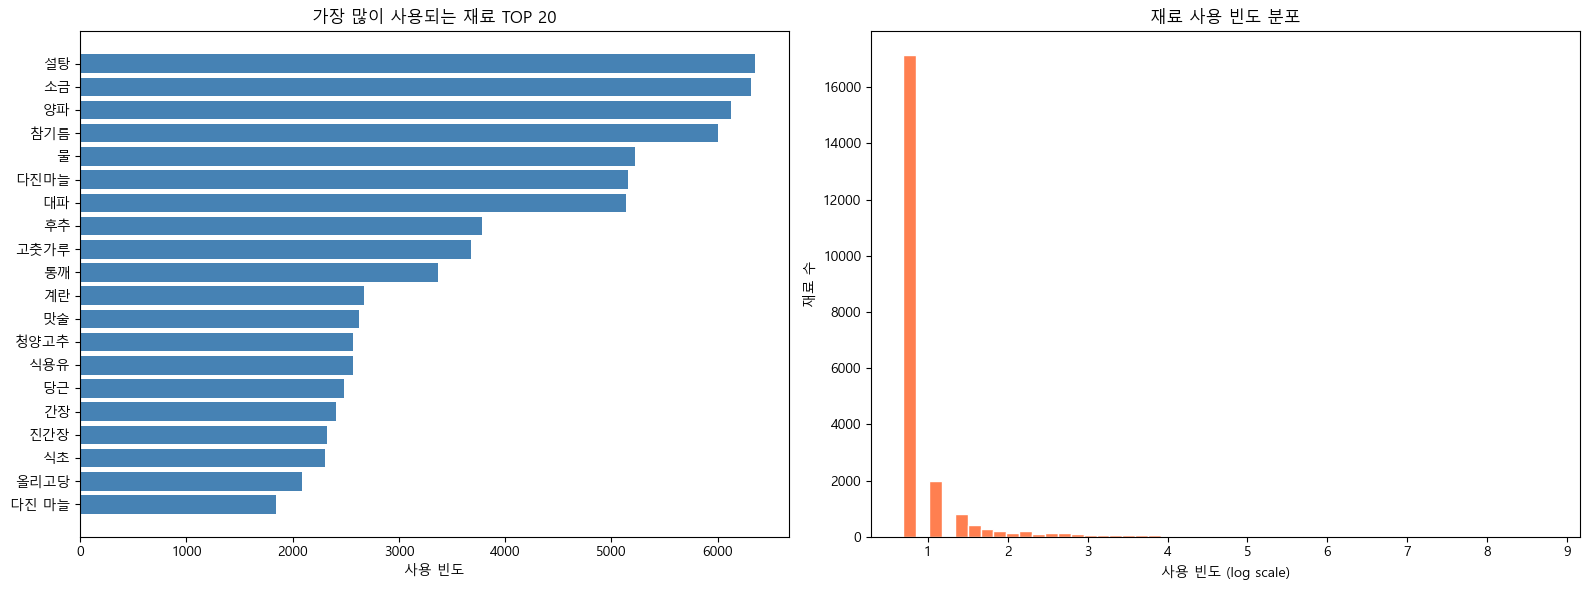

In [26]:
# 재료 빈도 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 상위 20개 재료 막대 그래프
top_20 = ingredient_freq.head(20)
axes[0].barh(range(len(top_20)), top_20.values, color='steelblue')
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20.index)
axes[0].invert_yaxis()
axes[0].set_xlabel('사용 빈도')
axes[0].set_title('가장 많이 사용되는 재료 TOP 20')

# 재료 빈도 분포 (로그 스케일)
axes[1].hist(np.log1p(ingredient_freq.values), bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('사용 빈도 (log scale)')
axes[1].set_ylabel('재료 수')
axes[1].set_title('재료 사용 빈도 분포')

plt.tight_layout()
plt.show()

## 2.6 재료명 정규화 (동의어 사전)

In [27]:
# 동의어 사전 정의
INGREDIENT_SYNONYMS = {
    # 채소류
    '양파': ['양파', '양파1개', '양파반개', '양파1/2개'],
    '마늘': ['마늘', '다진마늘', '다진 마늘', '마늘다진것', '깐마늘'],
    '대파': ['대파', '파', '쪽파', '실파'],
    '당근': ['당근', '홍당무'],
    '감자': ['감자', '감자알'],
    '양배추': ['양배추', '캐비지'],
    '고추': ['고추', '청양고추', '풋고추', '홍고추', '청고추'],
    
    # 단백질
    '소고기': ['소고기', '쇠고기', '한우', '소고기다짐육', '다진소고기'],
    '돼지고기': ['돼지고기', '돈육', '돼지', '삼겹살', '목살', '앞다리살'],
    '닭고기': ['닭고기', '닭', '닭가슴살', '닭다리', '닭날개'],
    '계란': ['계란', '달걀', '계란노른자', '계란흰자'],
    '두부': ['두부', '순두부', '연두부', '부침두부'],
    
    # 양념류
    '간장': ['간장', '진간장', '국간장', '양조간장', '조림간장'],
    '고추장': ['고추장', '태양초고추장'],
    '된장': ['된장', '재래된장'],
    '소금': ['소금', '꽃소금', '천일염', '굵은소금'],
    '설탕': ['설탕', '백설탕', '황설탕', '흑설탕'],
    '참기름': ['참기름', '들기름', '참깨기름'],
    '식용유': ['식용유', '식물성기름', '카놀라유', '포도씨유', '올리브유'],
    '후추': ['후추', '후춧가루', '통후추', '흑후추'],
    '고춧가루': ['고춧가루', '고추가루', '굵은고춧가루', '고운고춧가루'],
    
    # 곡류/면류
    '쌀': ['쌀', '백미', '멥쌀'],
    '밀가루': ['밀가루', '박력분', '중력분', '강력분'],
}

# 역방향 매핑 생성 (변형 -> 표준형)
synonym_to_standard = {}
for standard, synonyms in INGREDIENT_SYNONYMS.items():
    for syn in synonyms:
        synonym_to_standard[syn] = standard

print(f"동의어 사전 크기: {len(synonym_to_standard)}개 매핑")

동의어 사전 크기: 88개 매핑


In [28]:
# 제어 문자 제거 패턴
CONTROL_CHAR_PATTERN = re.compile(r'[\x00-\x1f\x7f-\x9f]')

def clean_ingredient_name(name):
    """재료명에서 수량/단위 제거하고 깨끗하게 정리"""
    if not name:
        return ''
    
    # 제어 문자 제거
    name = CONTROL_CHAR_PATTERN.sub('', str(name))
    name = name.strip()
    
    # 숫자가 있으면 숫자 이전까지만 추출
    # 예: "떡국떡400g" -> "떡국떡"
    num_match = re.search(r'\d', name)
    if num_match:
        name = name[:num_match.start()].strip()
    
    return name

def normalize_ingredient_name(name):
    """
    재료명을 정규화하는 함수 (개선된 버전)
    
    Args:
        name: 원본 재료명
    
    Returns:
        str: 정규화된 재료명
    """
    if not name:
        return ''
    
    # 1. 먼저 제어문자 및 수량/단위 제거
    name = clean_ingredient_name(name)
    
    if not name:
        return ''
    
    # 2. 동의어 사전에서 직접 매칭
    if name in synonym_to_standard:
        return synonym_to_standard[name]
    
    # 3. 부분 매칭 (재료명에 표준형이 포함된 경우)
    for standard in INGREDIENT_SYNONYMS.keys():
        if standard in name:
            return standard
    
    # 4. 매칭 실패 시 정리된 원본 반환
    return name

# 정규화 적용
df_ingredients['name_normalized'] = df_ingredients['name'].apply(normalize_ingredient_name)

# 빈 문자열 제거
df_ingredients = df_ingredients[df_ingredients['name_normalized'] != '']

# 정규화 전후 비교
normalized_freq = df_ingredients['name_normalized'].value_counts()
ingredient_freq_clean = df_ingredients['name'].apply(clean_ingredient_name).value_counts()

print(f"정규화 전 고유 재료 수: {len(ingredient_freq):,}개")
print(f"정리 후 고유 재료 수: {len(ingredient_freq_clean):,}개")
print(f"정규화 후 고유 재료 수: {len(normalized_freq):,}개")
print(f"감소율: {(1 - len(normalized_freq)/len(ingredient_freq))*100:.1f}%")

정규화 전 고유 재료 수: 22,272개
정리 후 고유 재료 수: 13,046개
정규화 후 고유 재료 수: 9,147개
감소율: 58.9%


In [29]:
# 정규화 후 상위 재료
print("정규화 후 가장 많이 사용되는 재료 TOP 30:")
print(normalized_freq.head(30))

정규화 후 가장 많이 사용되는 재료 TOP 30:
name_normalized
마늘      10434
소금       9939
대파       8019
간장       7801
참기름      7683
설탕       7352
양파       6942
고추       6466
물        6195
후추       5800
고춧가루     4765
계란       4291
식용유      3906
통깨       3525
당근       2937
맛술       2728
식초       2463
올리고당     2204
두부       1868
고추장      1793
감자       1756
굴소스      1544
밥        1490
참치액      1391
돼지고기     1279
오이       1230
무        1210
쌀        1198
소고기      1150
양배추      1057
Name: count, dtype: int64


## 2.7 재료 사전 구축

In [30]:
# 재료 사전 구축 (빈도 기반 필터링)
MIN_FREQUENCY = 5  # 최소 5회 이상 등장한 재료만 포함

ingredient_dict = normalized_freq[normalized_freq >= MIN_FREQUENCY].to_dict()

print(f"재료 사전 크기: {len(ingredient_dict):,}개")
print(f"(최소 {MIN_FREQUENCY}회 이상 등장한 재료)")

재료 사전 크기: 1,415개
(최소 5회 이상 등장한 재료)


In [31]:
# 재료 카테고리 자동 분류 (키워드 기반)
CATEGORY_KEYWORDS = {
    '채소': ['양파', '마늘', '파', '당근', '감자', '배추', '시금치', '상추', '오이', '호박', '버섯', '무', '콩나물', '양배추'],
    '육류': ['소고기', '돼지고기', '닭고기', '삼겹살', '목살', '안심', '등심', '갈비', '불고기'],
    '해산물': ['새우', '오징어', '조개', '굴', '게', '생선', '참치', '연어', '고등어', '멸치'],
    '양념': ['간장', '고추장', '된장', '소금', '설탕', '참기름', '후추', '고춧가루', '식초', '맛술'],
    '유제품': ['우유', '치즈', '버터', '크림', '요거트', '생크림'],
    '곡류': ['쌀', '밀가루', '면', '국수', '파스타', '빵', '떡'],
    '기타': []
}

def categorize_ingredient(name):
    """재료를 카테고리로 분류"""
    for category, keywords in CATEGORY_KEYWORDS.items():
        for keyword in keywords:
            if keyword in name:
                return category
    return '기타'

# 카테고리 분류 적용
df_ingredients['category'] = df_ingredients['name_normalized'].apply(categorize_ingredient)

# 카테고리별 분포
category_dist = df_ingredients['category'].value_counts()
print("재료 카테고리 분포:")
print(category_dist)

재료 카테고리 분포:
category
기타     79329
양념     51740
채소     45164
해산물     9146
곡류      4815
유제품     4492
육류      3675
Name: count, dtype: int64


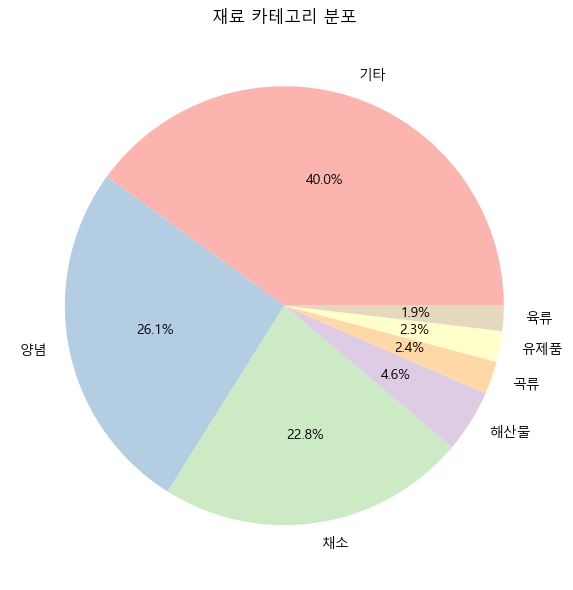

In [32]:
# 카테고리 분포 시각화
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.Pastel1.colors[:len(category_dist)]
ax.pie(category_dist.values, labels=category_dist.index, autopct='%1.1f%%', colors=colors)
ax.set_title('재료 카테고리 분포')

plt.tight_layout()
plt.show()

## 2.8 레시피-재료 관계 테이블 생성

In [33]:
# 레시피-재료 관계 데이터 생성 (개선된 버전)
recipe_ingredient_list = []

for recipe_id, ingredients in recipe_ingredients.items():
    for ing in ingredients:
        # 재료명 정규화 (수량/단위 제거 + 동의어 처리)
        normalized_name = normalize_ingredient_name(ing['name'])
        
        # 빈 문자열 건너뛰기
        if not normalized_name:
            continue
        
        recipe_ingredient_list.append({
            'recipe_id': recipe_id,
            'ingredient_name': clean_ingredient_name(ing['name']),  # 정리된 원본
            'ingredient_normalized': normalized_name,  # 정규화된 이름
            'quantity': ing['quantity'],
            'unit': ing['unit'],
            'section': ing['section']
        })

df_recipe_ingredients = pd.DataFrame(recipe_ingredient_list)
print(f"레시피-재료 관계 테이블 크기: {df_recipe_ingredients.shape}")

# 샘플 확인
print("\n샘플 데이터:")
print(df_recipe_ingredients.head(10))

레시피-재료 관계 테이블 크기: (198361, 6)

샘플 데이터:
   recipe_id ingredient_name ingredient_normalized quantity  unit section
0    7016813             떡국떡                   떡국떡      400     g      재료
1    7016813           다진소고기                   소고기      100     g      재료
2    7016813            멸치육수                  멸치육수      800    ml      재료
3    7016813              대파                    대파      1/3     대      재료
4    7016813              계란                    계란        2     개      재료
5    7016813             참기름                   참기름        1     T      재료
6    7016813             국간장                    간장        1     T      재료
7    7016813             참기름                   참기름      1/2     T      재료
8    7016813            다진마늘                    마늘        1     t      재료
9    7016813              소금                    소금     None  None      재료


In [34]:
# 역인덱스 생성 (재료 -> 레시피 목록)
ingredient_to_recipes = defaultdict(set)

for _, row in df_recipe_ingredients.iterrows():
    ing_name = row['ingredient_normalized']
    recipe_id = row['recipe_id']
    ingredient_to_recipes[ing_name].add(recipe_id)

# dict로 변환
ingredient_to_recipes = {k: list(v) for k, v in ingredient_to_recipes.items()}

print(f"역인덱스 크기: {len(ingredient_to_recipes):,}개 재료")
print(f"\n예시 - '양파'가 사용된 레시피 수: {len(ingredient_to_recipes.get('양파', []))}개")
print(f"예시 - '간장'이 사용된 레시피 수: {len(ingredient_to_recipes.get('간장', []))}개")

역인덱스 크기: 9,147개 재료

예시 - '양파'가 사용된 레시피 수: 6788개
예시 - '간장'이 사용된 레시피 수: 7369개


## 2.9 파싱 품질 평가

In [35]:
# 파싱 품질 메트릭
parsing_stats = {
    '총 레시피 수': len(recipe_ingredients),
    '재료 파싱 성공 레시피': sum(1 for v in recipe_ingredients.values() if len(v) > 0),
    '파싱 성공률(%)': sum(1 for v in recipe_ingredients.values() if len(v) > 0) / len(recipe_ingredients) * 100,
    '총 재료 인스턴스': len(all_ingredients),
    '고유 재료 수 (정규화 전)': len(ingredient_freq),
    '고유 재료 수 (정규화 후)': len(normalized_freq),
    '평균 레시피당 재료 수': len(all_ingredients) / len(recipe_ingredients),
}

print("=" * 60)
print("파싱 품질 평가 결과")
print("=" * 60)
for metric, value in parsing_stats.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.2f}")
    else:
        print(f"{metric}: {value:,}")

파싱 품질 평가 결과
총 레시피 수: 23,192
재료 파싱 성공 레시피: 23,191
파싱 성공률(%): 100.00
총 재료 인스턴스: 198,424
고유 재료 수 (정규화 전): 22,272
고유 재료 수 (정규화 후): 9,147
평균 레시피당 재료 수: 8.56


## 2.10 결과 저장

In [36]:
import pickle
import json

OUTPUT_DIR = '../data/processed'

# 1. 재료 DataFrame 저장
df_ingredients.to_csv(f'{OUTPUT_DIR}/ingredients_parsed.csv', index=False, encoding='utf-8-sig')
print(f"재료 데이터 저장: {OUTPUT_DIR}/ingredients_parsed.csv")

# 2. 레시피-재료 관계 테이블 저장
df_recipe_ingredients.to_csv(f'{OUTPUT_DIR}/recipe_ingredients.csv', index=False, encoding='utf-8-sig')
print(f"레시피-재료 관계 저장: {OUTPUT_DIR}/recipe_ingredients.csv")

# 3. 역인덱스 저장 (pickle)
with open(f'{OUTPUT_DIR}/ingredient_to_recipes.pkl', 'wb') as f:
    pickle.dump(ingredient_to_recipes, f)
print(f"역인덱스 저장: {OUTPUT_DIR}/ingredient_to_recipes.pkl")

# 4. 재료 사전 저장 (json)
with open(f'{OUTPUT_DIR}/ingredient_dict.json', 'w', encoding='utf-8') as f:
    json.dump(ingredient_dict, f, ensure_ascii=False, indent=2)
print(f"재료 사전 저장: {OUTPUT_DIR}/ingredient_dict.json")

# 5. 동의어 사전 저장 (json)
with open(f'{OUTPUT_DIR}/synonym_dict.json', 'w', encoding='utf-8') as f:
    json.dump(INGREDIENT_SYNONYMS, f, ensure_ascii=False, indent=2)
print(f"동의어 사전 저장: {OUTPUT_DIR}/synonym_dict.json")

print("\n✓ 2단계 완료!")
print("다음 단계: 03_recipe_gapfilling_model.ipynb에서 GapFilling 모델 구현")

재료 데이터 저장: ../data/processed/ingredients_parsed.csv
레시피-재료 관계 저장: ../data/processed/recipe_ingredients.csv
역인덱스 저장: ../data/processed/ingredient_to_recipes.pkl
재료 사전 저장: ../data/processed/ingredient_dict.json
동의어 사전 저장: ../data/processed/synonym_dict.json

✓ 2단계 완료!
다음 단계: 03_recipe_gapfilling_model.ipynb에서 GapFilling 모델 구현
